In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("IMDB_Dataset.csv")

In [2]:
df.shape

(50000, 2)

In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:

print(df['sentiment'].value_counts())

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [5]:
print(df['review'][0])

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fac

In [6]:
df['review_length'] = df['review'].apply(lambda x: len(x.split()))

print("Average review length:", df['review_length'].mean())

Average review length: 231.15694


In [7]:
print(df['review_length'].describe())

count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: review_length, dtype: float64


In [8]:
import re
import nltk
from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\Nihal -
[nltk_data]     Pooju\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [9]:
stop_words = set(stopwords.words('english'))

In [10]:
def preprocess_text(text):
    
    # 1. Lowercase
    text = text.lower()
    
    # 2. Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # 3. Remove punctuation
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    
    # 4. Tokenization (split into words)
    words = text.split()
    
    # 5. Remove stopwords
    words = [word for word in words if word not in stop_words]
    
    return words

In [11]:
df['cleaned_review'] = df['review'].apply(preprocess_text)

In [12]:
print("Original:\n", df['review'][0])
print("\nProcessed:\n", df['cleaned_review'][0])

Original:
 One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due

In [13]:
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df['cleaned_review'])

sequences = tokenizer.texts_to_sequences(df['cleaned_review'])

In [14]:
max_len = 200

X = pad_sequences(sequences, maxlen=max_len)

In [15]:
y = df['sentiment'].map({'positive': 1, 'negative': 0})

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

vocab_size = 5000  # limit vocabulary

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")

In [17]:
tokenizer.fit_on_texts(df['cleaned_review'])

In [18]:
sequences = tokenizer.texts_to_sequences(df['cleaned_review'])

In [19]:
word_index = tokenizer.word_index

for word, index in list(word_index.items())[:10]:
    print(word, ":", index)

<OOV> : 1
movie : 2
film : 3
one : 4
like : 5
good : 6
time : 7
even : 8
would : 9
story : 10


In [20]:
max_review_length = df['review_length'].max()
print("Max length:", max_review_length)

Max length: 2470


In [21]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 200

X = pad_sequences(sequences, maxlen=max_len)

In [22]:
print(sequences[0])

[4, 1898, 917, 56, 2916, 276, 3030, 99, 488, 465, 20, 55, 3075, 2916, 1, 1, 50, 435, 154, 99, 521, 52, 1584, 39, 1, 2171, 1, 39, 2429, 1, 1, 1320, 255, 435, 3640, 240, 241, 521, 312, 2916, 1, 242, 1, 1, 2402, 898, 1, 2543, 1264, 1, 396, 4495, 2296, 1048, 1, 2743, 1, 268, 1, 1, 184, 4706, 2744, 396, 226, 32, 1, 1, 1, 1, 4848, 1, 2285, 1, 209, 1, 1, 1, 1, 1, 35, 117, 132, 9, 49, 168, 1180, 39, 550, 91, 155, 162, 2852, 688, 81, 1157, 3980, 2331, 1079, 688, 1285, 688, 734, 2916, 806, 83, 20, 276, 43, 105, 3075, 1467, 2079, 49, 1430, 178, 1269, 1121, 2916, 89, 1, 184, 1877, 1974, 435, 435, 1, 1, 4818, 2813, 1, 1, 372, 501, 16, 132, 13, 1, 512, 567, 1, 523, 1048, 1, 550, 440, 760, 1860, 1048, 425, 56, 2916, 95, 305, 3658, 3143, 665, 1445, 16, 1066, 3916, 357]


In [23]:
print(X[0])

[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    4 1898  917   56
 2916  276 3030   99  488  465   20   55 3075 2916    1    1   50  435
  154   99  521   52 1584   39    1 2171    1   39 2429    1    1 1320
  255  435 3640  240  241  521  312 2916    1  242    1    1 2402  898
    1 2543 1264    1  396 4495 2296 1048    1 2743    1  268    1    1
  184 4706 2744  396  226   32    1    1    1    1 4848    1 2285    1
  209    1    1    1    1    1   35  117  132    9   49  168 1180   39
  550   91  155  162 2852  688   81 1157 3980 2331 1079  688 1285  688
  734 2916  806   83   20  276   43  105 3075 1467 2079   49 1430  178
 1269 1121 2916   89    1  184 1877 1974  435  435    1    1 4818 2813
    1    1  372  501   16  132   13    1  512  567    1  523 1048    1
  550  440  760 1860 1048  425   56 2916   95  305 3658 3143  665 1445
   16 

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

In [25]:
model = Sequential()

In [26]:
model.add(Embedding(input_dim=5000, output_dim=64, input_length=200))

c:\Users\Nihal - Pooju\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [27]:
model.add(SimpleRNN(64))

In [28]:
model.add(Dense(1, activation='sigmoid'))


In [29]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [30]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 47ms/step - accuracy: 0.7841 - loss: 0.4406 - val_accuracy: 0.8429 - val_loss: 0.3555
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 47ms/step - accuracy: 0.8726 - loss: 0.3115 - val_accuracy: 0.8452 - val_loss: 0.3985
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 52ms/step - accuracy: 0.8966 - loss: 0.2576 - val_accuracy: 0.8627 - val_loss: 0.3480
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 49ms/step - accuracy: 0.9156 - loss: 0.2159 - val_accuracy: 0.8578 - val_loss: 0.3889
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 47ms/step - accuracy: 0.9172 - loss: 0.2012 - val_accuracy: 0.8439 - val_loss: 0.4342


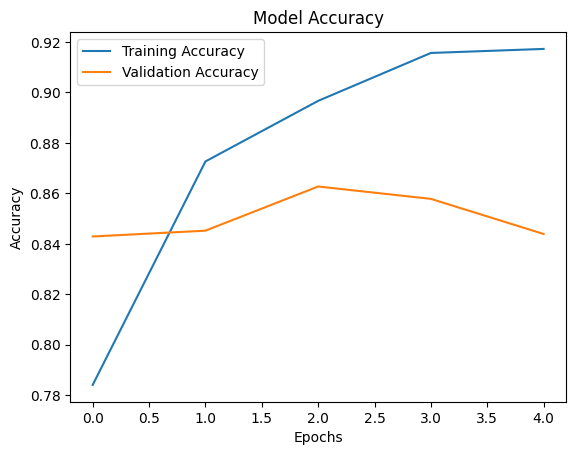

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8439 - loss: 0.4342

Test Accuracy: 0.8439000248908997
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step

Confusion Matrix:
 [[4223  738]
 [ 823 4216]]

Precision: 0.8510294711344368
Recall: 0.8366739432427069

Some Misclassified Reviews:

Review: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inw

In [31]:
# ================================
# TASK 7 — TRAIN THE MODEL
# ================================

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# 1. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test)
)

# 3. Plot Accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


# ================================
# TASK 8 — EVALUATE MODEL
# ================================

from sklearn.metrics import confusion_matrix, precision_score, recall_score

# 1. Evaluate Accuracy
loss, accuracy = model.evaluate(X_test, y_test)
print("\nTest Accuracy:", accuracy)

# 2. Predictions
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

# 3. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# 4. Precision & Recall
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("\nPrecision:", precision)
print("Recall:", recall)

# 5. Misclassified Reviews
misclassified = np.where(y_test != y_pred.flatten())[0]

print("\nSome Misclassified Reviews:")
for i in misclassified[:5]:
    print("\nReview:", df['review'].iloc[i])
    print("Actual:", y_test.iloc[i])
    print("Predicted:", y_pred[i][0])